In [1]:

import os
import pandas as pd
import numpy as np
import pywt
from scipy import signal, stats
from matplotlib import font_manager, rcParams
import pathlib
from matplotlib import pyplot as plt
# 设置中文字体（可选）
font_path = "../wqy-zenhei.ttc"
font_manager.fontManager.addfont(font_path)
font_prop = font_manager.FontProperties(fname=font_path)
rcParams['font.sans-serif'] = [font_prop.get_name()]
rcParams['axes.unicode_minus'] = False

In [2]:


# 采样参数
FS = 25600


WINDOW_SIZE = 5   # 滑动窗口大小（计算局部均值）
TREND_SIZE = 10   # 趋势计算窗口大小

# %%
def compute_psd(x, fs=FS, nperseg=None):
    if nperseg is None:
        nperseg = min(len(x), 4096)
    freqs, psd = signal.welch(x - np.mean(x), fs=fs, window='hann', nperseg=nperseg)
    return freqs, psd

def extract_time_features(x):
    rms = np.sqrt(np.mean(x**2))
    peak = np.max(np.abs(x))
    return {
        "rms": rms,
        "std": np.std(x),
        "mean": np.mean(x),
        "kurtosis": stats.kurtosis(x),
        "skewness": stats.skew(x),
        "peak2peak": np.ptp(x),
        "crest_factor": peak / (rms + 1e-12),
        "impulse_factor": peak / (np.mean(np.abs(x)) + 1e-12),
        "clearance_factor": peak / ((np.mean(np.sqrt(np.abs(x)))**2) + 1e-12),
    }

def extract_psd_features(x, fs=FS, n_bins=10):
    freqs, psd = compute_psd(x, fs)
    psd_energy = psd.sum() + 1e-12
    psd_norm = psd / psd_energy
    centroid = np.sum(freqs * psd_norm)
    bandwidth = np.sqrt(np.sum(((freqs - centroid)**2) * psd_norm))
    entropy = -np.sum(psd_norm * np.log(psd_norm + 1e-12))
    flatness = np.exp(np.mean(np.log(psd + 1e-12))) / (np.mean(psd) + 1e-12)
    feats = {
        "psd_energy": psd_energy,
        "spectral_entropy": entropy,
        "spectral_centroid": centroid,
        "spectral_bandwidth": bandwidth,
        "spectral_flatness": flatness
    }
    # 分频能量
    fmax = freqs[-1]
    bins = np.linspace(0, fmax, n_bins+1)
    for i in range(n_bins):
        idx = (freqs >= bins[i]) & (freqs < bins[i+1])
        feats[f"psd_bin_energy_{i}"] = psd[idx].sum() / psd_energy
    return feats

def extract_envelope_features(x, fs=FS, n_bins=8):
    analytic = signal.hilbert(x - np.mean(x))
    env = np.abs(analytic)
    env -= env.mean()
    freqs, psd_env = compute_psd(env, fs)
    psd_env += 1e-12
    psd_env_norm = psd_env / psd_env.sum()
    centroid = np.sum(freqs * psd_env_norm)
    entropy = -np.sum(psd_env_norm * np.log(psd_env_norm + 1e-12))
    feats = {
        "env_rms": np.sqrt(np.mean(env**2)),
        "env_kurtosis": stats.kurtosis(env),
        "env_entropy": entropy,
        "env_centroid": centroid
    }
    fmax = freqs[-1]
    bins = np.linspace(0, fmax, n_bins+1)
    for i in range(n_bins):
        idx = (freqs >= bins[i]) & (freqs < bins[i+1])
        feats[f"env_bin_energy_{i}"] = psd_env[idx].sum() / psd_env.sum()
    return feats

def extract_wavelet_features(x):
    x = x - np.mean(x)
    coeffs = pywt.wavedec(x, 'db4', level=4)
    energies = np.array([np.sum(c**2) for c in coeffs])
    total_energy = energies.sum() + 1e-12
    high_ratio = (energies[-1] + energies[-2]) / total_energy
    energy_norm = energies / total_energy
    wavelet_entropy = -np.sum(energy_norm * np.log(energy_norm + 1e-12))
    return {
        "wavelet_energy": total_energy,
        "wavelet_high_ratio": high_ratio,
        "wavelet_entropy": wavelet_entropy
    }

def extract_features(x, fs=FS):
    feats = {}
    feats.update(extract_time_features(x))
    feats.update(extract_psd_features(x, fs))
    feats.update(extract_envelope_features(x, fs))
    feats.update(extract_wavelet_features(x))
    return feats

In [3]:
def process_bearing_folder(folder, delta_t=10):
    acc_files = sorted([os.path.join(folder, f) for f in os.listdir(folder)
                        if f.startswith("acc") and f.endswith(".csv")])
    
    feats_list = []
    for file in acc_files:
        try:
            df = pd.read_csv(file, header=None, sep=',').to_numpy()
            sig = np.sqrt(df[:,4]**2 + df[:,5]**2 ) 
        except:
            df= pd.read_csv(file, header=None, sep=';').to_numpy()
            sig = np.sqrt(df[:,4]**2 + df[:,5]**2 ) 
            
        # TODO：这里可以考虑增加一些数据清洗步骤，比如去除异常值、平滑信号等
        feats_list.append(extract_features(sig))
    df_feats = pd.DataFrame(feats_list)
    
    # 1. 
    df_smooth = df_feats.ewm(alpha=0.3).mean()
    df_smooth.columns = [f"{c}_smooth" for c in df_smooth.columns]
    df_feats = pd.concat([df_feats, df_smooth], axis=1)
   
    # 2. RUL 标签（真实秒数，不泄漏未来信息）
    rul = np.arange(len(acc_files)-1, -1, -1) * delta_t
    df_feats['RUL'] = rul
    # 3. 
    sub = pathlib.Path(folder).stem
    df_feats['bearing_id'] = sub
    
    return df_feats

In [4]:
bearing1_1 = "./phm-ieee-2012-data-challenge-dataset-master/Learning_set/Bearing3_2"
df = process_bearing_folder(bearing1_1)

df


,rms,std,mean,kurtosis,skewness,peak2peak,crest_factor,impulse_factor,clearance_factor,psd_energy,...,env_bin_energy_3_smooth,env_bin_energy_4_smooth,env_bin_energy_5_smooth,env_bin_energy_6_smooth,env_bin_energy_7_smooth,wavelet_energy_smooth,wavelet_high_ratio_smooth,wavelet_entropy_smooth,RUL,bearing_id
0,0.428571,0.207656,0.374903,0.693252,0.798871,1.337860,3.128677,3.576554,3.885005,0.004079,...,0.117433,0.130851,0.065434,0.039263,0.023264,111.017479,0.577599,1.482407,16360,Bearing3_2
1,0.419409,0.204558,0.366142,0.739177,0.857344,1.255205,3.014777,3.453372,3.752862,0.004509,...,0.120480,0.163577,0.055444,0.036627,0.021426,109.997205,0.591576,1.481593,16350,Bearing3_2
2,0.440443,0.220118,0.381494,2.655117,1.135670,2.016226,4.593782,5.303611,5.781547,0.004253,...,0.117337,0.152255,0.055792,0.036494,0.021717,121.002389,0.568612,1.484592,16340,Bearing3_2
3,0.429883,0.207301,0.376598,0.373581,0.735380,1.265114,2.954788,3.372866,3.664225,0.004470,...,0.120357,0.141934,0.054772,0.034719,0.021824,117.199041,0.584513,1.485489,16330,Bearing3_2
4,0.470348,0.239402,0.404863,1.555931,1.059002,1.687539,3.623994,4.210164,4.607396,0.005092,...,0.117033,0.143436,0.053538,0.036297,0.020464,128.655522,0.576261,1.485346,16320,Bearing3_2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1632,2.855281,1.707232,2.288665,7.501264,2.134417,16.633088,5.836375,7.281314,8.213892,0.291561,...,0.058246,0.043914,0.041743,0.034905,0.027256,6478.694852,0.386052,1.401974,40,Bearing3_2
1633,2.780168,1.639947,2.244974,18.284114,2.786190,23.923775,8.621046,10.676272,11.947833,0.349781,...,0.055525,0.055296,0.039267,0.030719,0.024030,6616.538611,0.384291,1.414646,30,Bearing3_2
1634,2.866720,1.679446,2.323261,7.154714,2.123462,15.644329,5.469237,6.748603,7.555898,0.314723,...,0.060485,0.054491,0.038202,0.032217,0.022537,6831.790176,0.393649,1.412856,20,Bearing3_2
1635,3.303656,2.046096,2.593769,12.843303,2.735815,21.741490,6.590305,8.394002,9.499347,0.297777,...,0.061170,0.055006,0.038521,0.033454,0.026019,8030.298116,0.379674,1.395297,10,Bearing3_2


0.0 1.0


<Axes: >

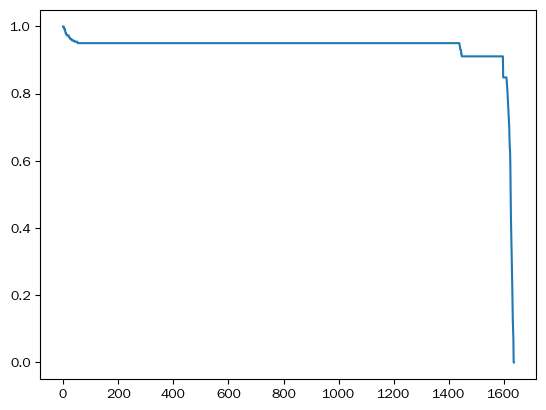

In [5]:
# 保证单调下滑
hi_label = 1 - (df['rms_smooth'] - df['rms_smooth'].min()) / (df['rms_smooth'].max() - df['rms_smooth'].min())
hi_label = hi_label.cummin() # 如果设备维修了，那这行代码就会有问题
# 再重新归一化
hi_label = (hi_label - hi_label.min()) / (hi_label.max() - hi_label.min())

print(hi_label.min(), hi_label.max())
hi_label.plot()

0.0 1.0


<Axes: title={'center': 'PCA-based HI'}>

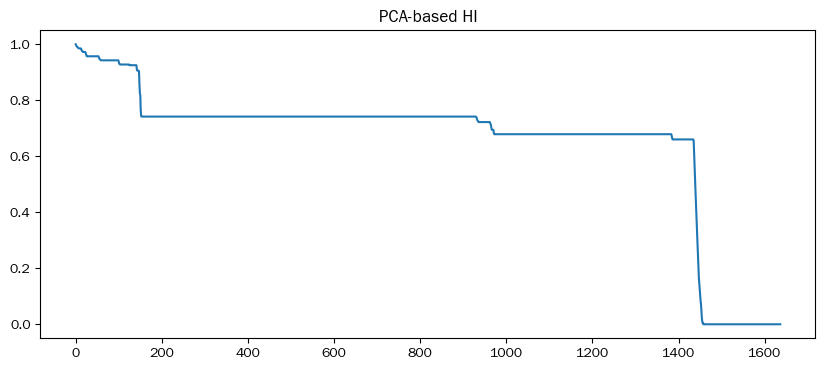

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# 1. 取平滑后的特征
smooth_cols = [c for c in df.columns if c.endswith('_smooth')]
X_smooth = df[smooth_cols].values

# 2. 标准化
X_scaled = StandardScaler().fit_transform(X_smooth)

# 3. PCA
pca = PCA(n_components=1)
hi_raw = pca.fit_transform(X_scaled).flatten()
correlation = np.corrcoef(np.arange(len(hi_raw)), hi_raw)[0, 1]
if correlation > 0:
    hi_raw = -hi_raw

hi_norm = (hi_raw - hi_raw.min()) / (hi_raw.max() - hi_raw.min())
hi_smooth = pd.Series(hi_norm).ewm(alpha=0.1, adjust=False).mean()
hi_final = hi_smooth.cummin()
hi_final = (hi_final - hi_final.min()) / (hi_final.max() - hi_final.min())

print(hi_final.min(), hi_final.max())
# 7. 可视化
hi_final.plot(figsize=(10,4), title='PCA-based HI')



结论：使用rms_smooth来作为HI label展示即可，PCA方法不行

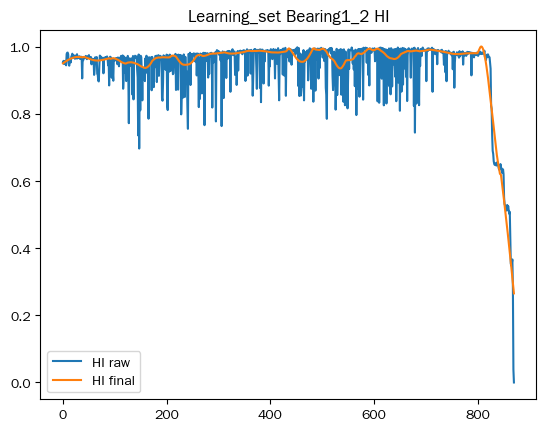

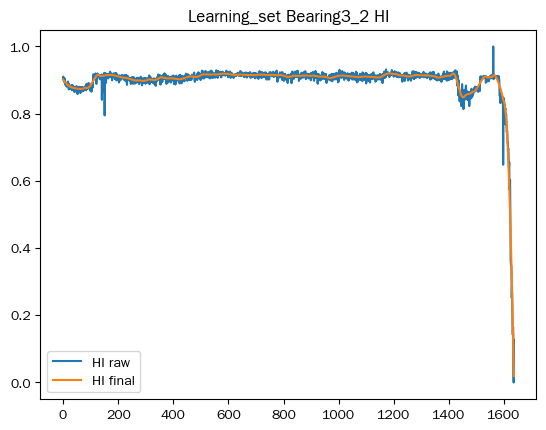

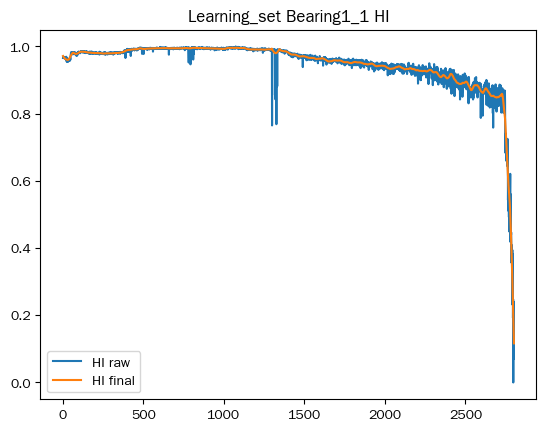

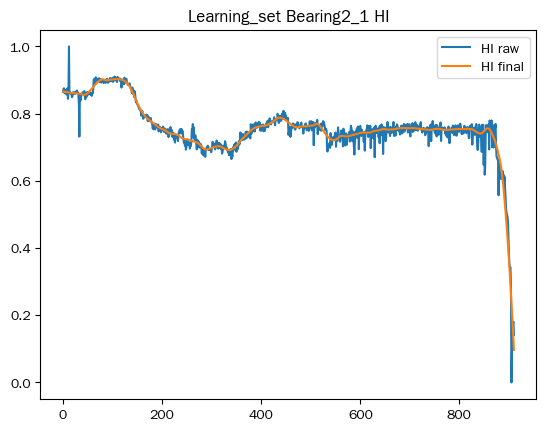

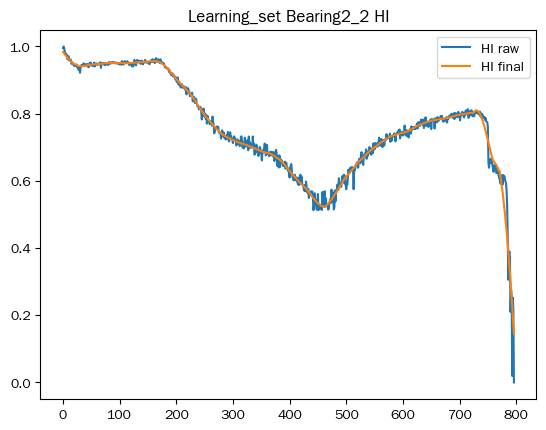

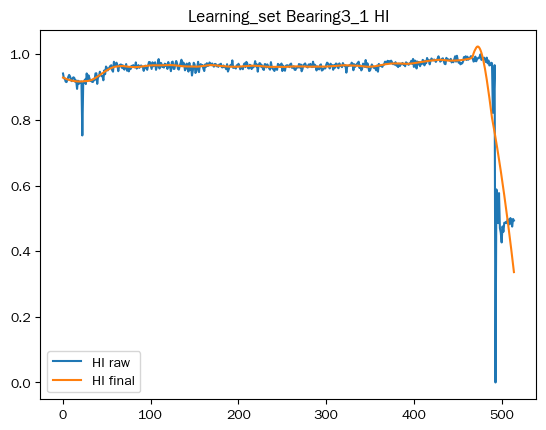

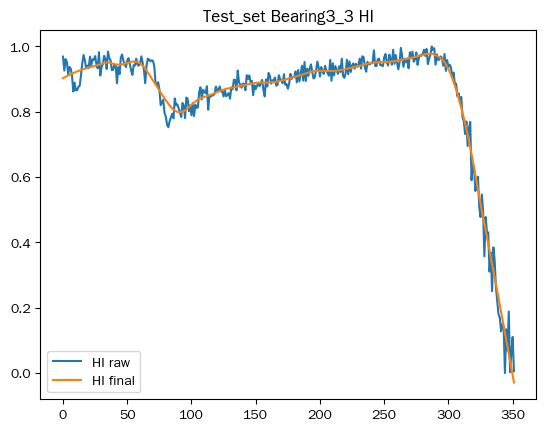

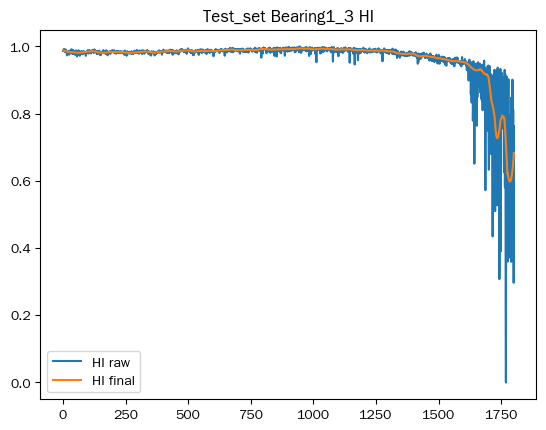

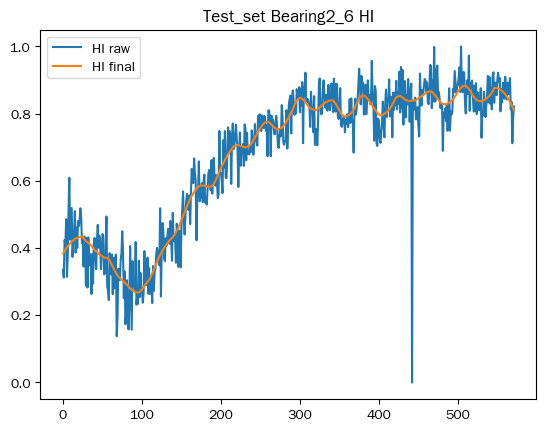

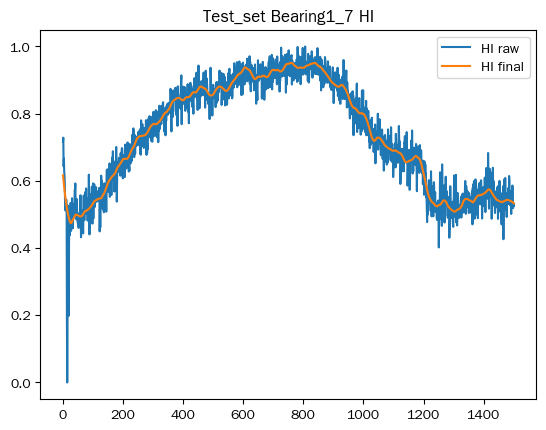

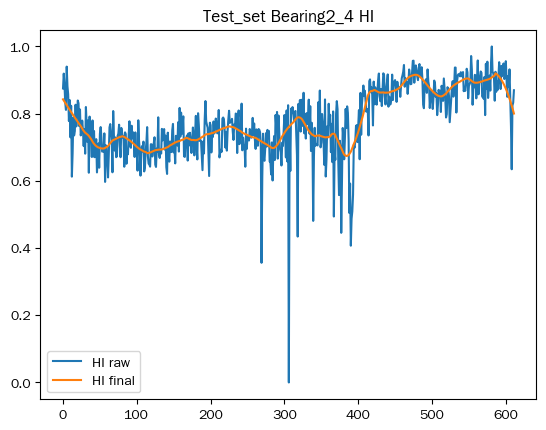

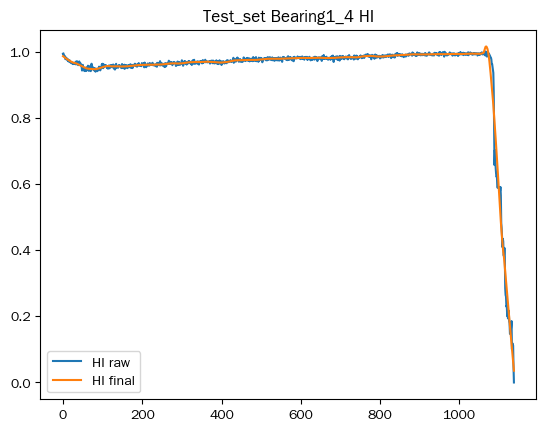

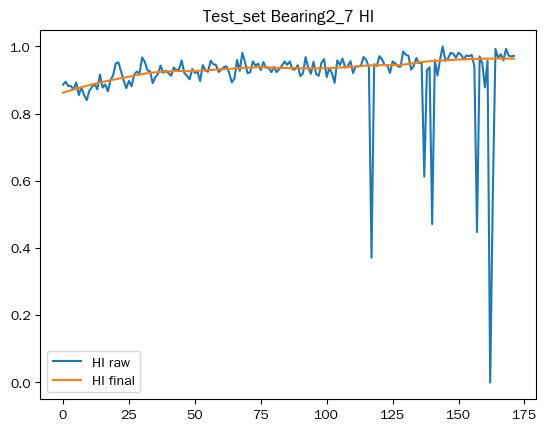

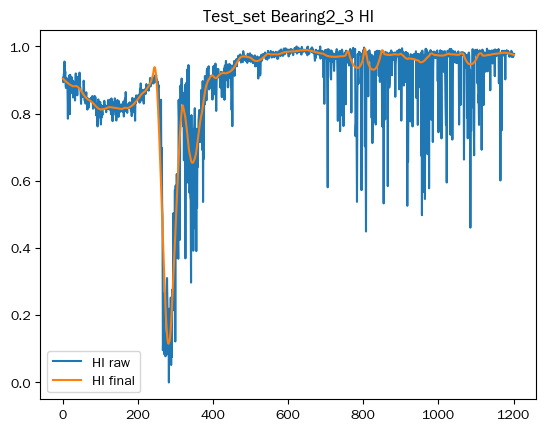

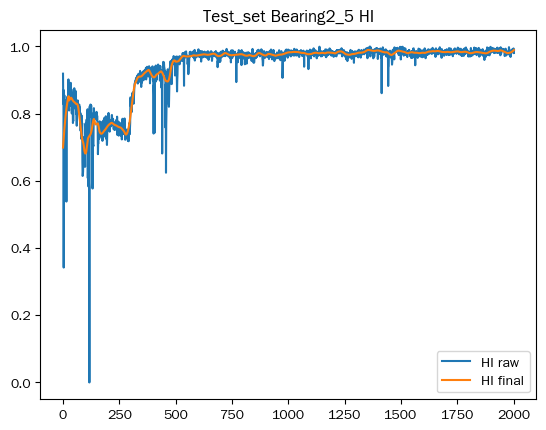

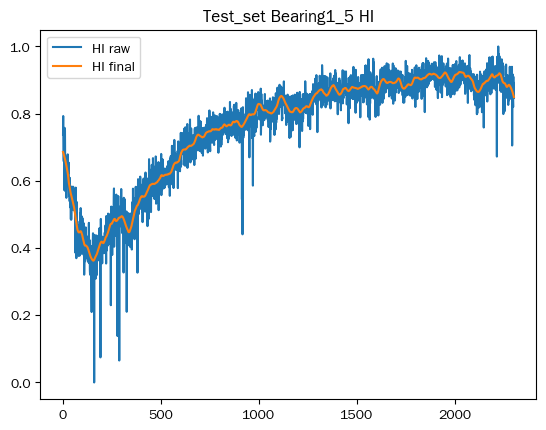

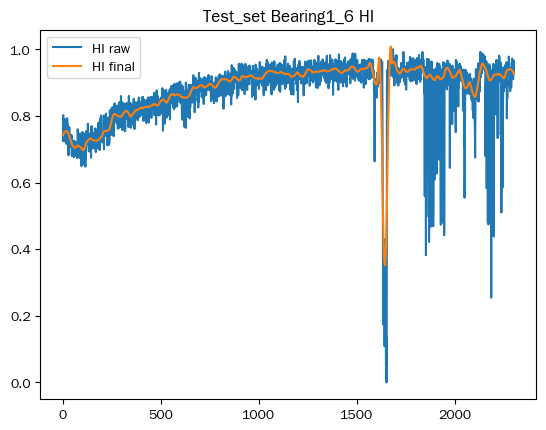

In [7]:
from scipy.signal import savgol_filter, medfilt

train_folder = "./phm-ieee-2012-data-challenge-dataset-master/Learning_set"
test_folder = "./phm-ieee-2012-data-challenge-dataset-master/Test_set"

for folder in [train_folder, test_folder]:
    for sub in os.listdir(folder):
        if sub.startswith("Bearing"):
            df = process_bearing_folder(os.path.join(folder, sub))
            HI_raw = 1 - (df['rms'] - df['rms'].min()) / (df['rms'].max() - df['rms'].min())
            HI_denoised = medfilt(HI_raw, kernel_size=11)
        
            HI_final = savgol_filter(HI_denoised, window_length=51, polyorder=2)
            
            plt.figure()
            plt.title(f'{folder.split("/")[-1]} {sub} HI')
            plt.plot(HI_raw, label='HI raw')
            # plt.plot(HI_smooth, label='HI smooth')
            plt.plot(HI_final, label='HI final')
            plt.legend()
            plt.show()